# Accuracy benchmark — FINd_optimized vs pHash vs wHash

Goal: compare the three perceptual hashes on the meme_images dataset (1035 ground-truth clusters of ≥10 near-duplicates each). Headline metric is **TPR @ FPR=1%** — the business-aligned framing for content moderation (use case A, evaluation_criteria.md §1).

Sections:
1. Setup + cluster index.
2. Stratified pair sample (1000 within + 1000 between).
3. Hash all unique images (3 methods × 256-bit).
4. Pair distances.
5. Distribution analysis (within vs between).
6. ROC curves + AUC.
7. Operating-points table (TPR @ FPR ∈ {0.1%, 0.5%, 1%, 5%}).
8. Computational cost comparison (latency on N=100).
9. Summary JSON + acceptance-bar auto-fill.
10. HTML report export.

Method choices:
- **FINd_optimized** — our numpy-vectorised hasher.
- **pHash (256-bit)** — DCT-based; literature anchor for criteria A1/A2.
- **wHash (256-bit, Haar)** — wavelet-based; methodologically distinct (different math basis vs FINd's DCT).

## 1. Setup

In [1]:
import sys, os, json, random, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imagehash

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from FINd_optimized import FINDHasherOptimized

IMG_DIR = PROJECT_ROOT / 'meme_images'
FIG_DIR = PROJECT_ROOT / 'figures' / 'accuracy'
SUMMARIES_DIR = PROJECT_ROOT / 'summaries'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUMMARIES_DIR.mkdir(exist_ok=True)

SEED = 99
PAIRS_PER_CLUSTER = 5
N_WITHIN_CLUSTERS = 200       # 200 × 5 = 1000 within-pairs
N_BETWEEN_REPRESENTATIVES = 500  # 500 reps → sample 1000 between-pairs
N_BETWEEN_PAIRS = 1000

print(f'Project root: {PROJECT_ROOT}')
print(f'imagehash version: {imagehash.__version__}')

Project root: /Users/alena/ms_ox/sds/summative2026
imagehash version: 4.3.2


## 2. Cluster index + stratified pair sample

The dataset filename convention is `XXXX_NNNNNNNN.jpg` where `XXXX` is the cluster ID. Same-cluster pairs are presumed near-duplicates (ground-truth positive); different-cluster pairs are presumed non-duplicates (ground-truth negative).

**Stratified sampling rationale**: cluster sizes range 10–766. Random within-pair sampling would over-represent large clusters (more pairs per cluster). Stratified sampling — fixed pairs per cluster, fixed reps per between-cluster — gives equal weight to each meme family.

In [2]:
# Build cluster index: cluster_id -> list of filenames
clusters = defaultdict(list)
for f in sorted(os.listdir(IMG_DIR)):
    cluster_id = f.split('_')[0]
    clusters[cluster_id].append(f)

n_clusters = len(clusters)
sizes = [len(v) for v in clusters.values()]
print(f'Total clusters: {n_clusters}')
print(f'Cluster size: min={min(sizes)}, median={int(np.median(sizes))}, max={max(sizes)}')

rng = random.Random(SEED)

# WITHIN pairs: stratified — 5 random pairs from each of 200 random clusters
all_cluster_ids = list(clusters.keys())
rng.shuffle(all_cluster_ids)
within_cluster_ids = all_cluster_ids[:N_WITHIN_CLUSTERS]

within_pairs = []
for cid in within_cluster_ids:
    files = clusters[cid]
    # All possible pairs in this cluster
    all_pairs = [(files[i], files[j]) for i in range(len(files)) for j in range(i+1, len(files))]
    sampled = rng.sample(all_pairs, min(PAIRS_PER_CLUSTER, len(all_pairs)))
    for a, b in sampled:
        within_pairs.append((a, b, cid, cid))

# BETWEEN pairs: pick 1 representative per cluster from a different 500 clusters,
# then sample 1000 pairs from C(500, 2) = 124,750 possibilities
between_cluster_ids = all_cluster_ids[N_WITHIN_CLUSTERS:N_WITHIN_CLUSTERS + N_BETWEEN_REPRESENTATIVES]
representatives = {cid: rng.choice(clusters[cid]) for cid in between_cluster_ids}

between_pairs_pool = [
    (representatives[a], representatives[b], a, b)
    for i, a in enumerate(between_cluster_ids)
    for b in between_cluster_ids[i+1:]
]
between_pairs = rng.sample(between_pairs_pool, min(N_BETWEEN_PAIRS, len(between_pairs_pool)))

print(f'WITHIN pairs:  {len(within_pairs)}  (from {N_WITHIN_CLUSTERS} clusters × ≤{PAIRS_PER_CLUSTER} pairs)')
print(f'BETWEEN pairs: {len(between_pairs)} (from {N_BETWEEN_REPRESENTATIVES} representatives, sampled from C({N_BETWEEN_REPRESENTATIVES},2))')

# Collect all unique filenames we need to hash
unique_files = set()
for a, b, _, _ in within_pairs + between_pairs:
    unique_files.add(a); unique_files.add(b)
unique_files = sorted(unique_files)
print(f'Unique images to hash: {len(unique_files)}')

Total clusters: 1035
Cluster size: min=10, median=24, max=766
WITHIN pairs:  1000  (from 200 clusters × ≤5 pairs)


BETWEEN pairs: 1000 (from 500 representatives, sampled from C(500,2))
Unique images to hash: 2176


## 3. Hash all unique images — three methods × 256-bit

We hash each unique file once per method and cache. Pair-level distances are then computed as `hash[a] - hash[b]` (Hamming, via `imagehash.ImageHash.__sub__`).

All three methods use **256-bit hashes** (16×16) for apples-to-apples comparison:
- FINd_optimized: native 256-bit
- pHash: `hash_size=16` (DCT 16×16)
- wHash: `hash_size=16, mode='haar'` (Haar wavelet 16×16)

In [3]:
find = FINDHasherOptimized()

methods = {
    'find':  lambda path: find.fromFile(str(path)),
    'phash': lambda path: imagehash.phash(Image.open(path), hash_size=16),
    'whash': lambda path: imagehash.whash(Image.open(path), hash_size=16, mode='haar'),
}

hashes = {m: {} for m in methods}
timing = {m: 0.0 for m in methods}

for m, fn in methods.items():
    t0 = time.perf_counter()
    for f in unique_files:
        hashes[m][f] = fn(IMG_DIR / f)
    timing[m] = time.perf_counter() - t0
    print(f'{m:6s}: hashed {len(unique_files)} images in {timing[m]:.2f}s ({timing[m]/len(unique_files)*1000:.2f} ms/img)')

find  : hashed 2176 images in 11.09s (5.10 ms/img)


phash : hashed 2176 images in 6.17s (2.83 ms/img)


whash : hashed 2176 images in 10.39s (4.78 ms/img)


## 4. Pair distances → DataFrame for analysis

In [4]:
rows = []
for (a, b, ca, cb), label in [(p, 'within') for p in within_pairs] + [(p, 'between') for p in between_pairs]:
    row = {'file_a': a, 'file_b': b, 'cluster_a': ca, 'cluster_b': cb, 'label': label}
    for m in methods:
        row[f'd_{m}'] = hashes[m][a] - hashes[m][b]
    rows.append(row)
df = pd.DataFrame(rows)
df.head()

,file_a,file_b,cluster_a,cluster_b,label,d_find,d_phash,d_whash
0,0555_13551459.jpg,0555_13554694.jpg,0555,0555,within,98,86,50
1,0555_14141165.jpg,0555_17674094.jpg,0555,0555,within,66,66,50
2,0555_13552952.jpg,0555_14141165.jpg,0555,0555,within,88,86,50
3,0555_14141336.jpg,0555_34600335.jpg,0555,0555,within,78,70,40
4,0555_13550735.jpg,0555_34507392.jpg,0555,0555,within,78,72,46


In [5]:
# Save raw pair distances for reproducibility / further analysis
df.to_csv(SUMMARIES_DIR / 'accuracy_pairs.csv', index=False)
print(f'Saved {len(df)} pair distances → summaries/accuracy_pairs.csv')

Saved 2000 pair distances → summaries/accuracy_pairs.csv


## 5. Distribution analysis — within vs between

Discrimination = `mean_between - mean_within` (criteria A3 ≥ 50 bits).

A larger gap means easier threshold-based classification.

In [6]:
dist_stats = []
for m in methods:
    within_d  = df[df.label == 'within'][f'd_{m}']
    between_d = df[df.label == 'between'][f'd_{m}']
    dist_stats.append({
        'method': m,
        'mean_within': within_d.mean(),
        'mean_between': between_d.mean(),
        'discrimination': between_d.mean() - within_d.mean(),
        'std_within': within_d.std(),
        'std_between': between_d.std(),
        'min_between': between_d.min(),
        'max_within': within_d.max(),
        'overlap_zone': max(0, within_d.max() - between_d.min()),
    })
dist_df = pd.DataFrame(dist_stats).set_index('method')
print(dist_df.round(2).to_string())

        mean_within  mean_between  discrimination  std_within  std_between  min_between  max_within  overlap_zone
method                                                                                                           
find          54.68        127.25           72.57       22.04         8.94          102         136            34
phash         51.89        126.45           74.56       21.71         8.80           98         134            36
whash         30.33        126.52           96.20       19.96        22.67           46         142            96


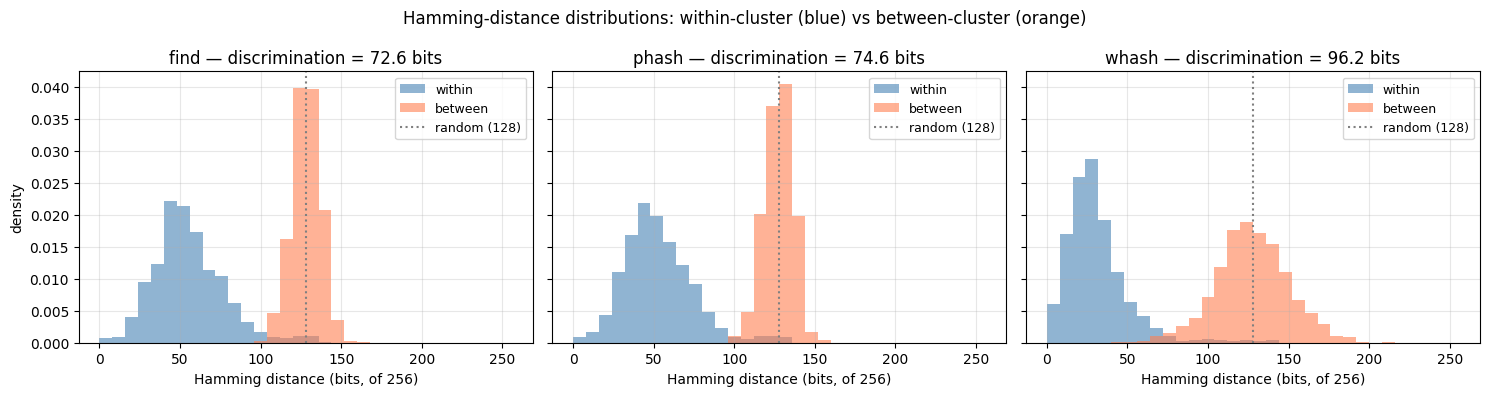

In [7]:
# Distribution overlay: 3 methods × (within / between)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, m in zip(axes, methods):
    within_d  = df[df.label == 'within'][f'd_{m}']
    between_d = df[df.label == 'between'][f'd_{m}']
    bins = np.arange(0, 257, 8)
    ax.hist(within_d,  bins=bins, alpha=0.6, label='within',  color='steelblue', density=True)
    ax.hist(between_d, bins=bins, alpha=0.6, label='between', color='coral', density=True)
    ax.axvline(128, color='gray', linestyle=':', label='random (128)')
    ax.set_xlabel('Hamming distance (bits, of 256)')
    ax.set_title(f'{m} — discrimination = {dist_df.loc[m, "discrimination"]:.1f} bits')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel('density')
fig.suptitle('Hamming-distance distributions: within-cluster (blue) vs between-cluster (orange)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC curves + AUC

Vary the threshold from 0 to 256 bits; for each threshold compute TPR (recall on near-duplicates) and FPR (false alarms on different memes).

ROC integrates these into a single quality measure (AUC). Higher AUC = better overall discrimination.

find  : AUC = 0.9897
phash : AUC = 0.9907
whash : AUC = 0.9921


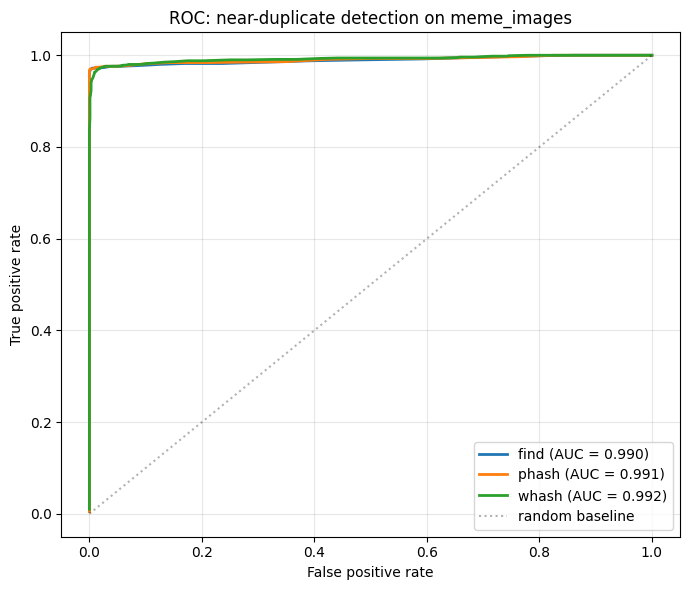

In [8]:
def roc_curve(within_d, between_d):
    """Sort distances, sweep threshold, compute (FPR, TPR) for each."""
    thresholds = np.arange(0, 257)  # bit thresholds
    tpr = np.array([(within_d  <= t).mean() for t in thresholds])
    fpr = np.array([(between_d <= t).mean() for t in thresholds])
    auc = np.trapezoid(tpr, fpr)  # area under ROC
    return thresholds, tpr, fpr, auc

roc_data = {}
for m in methods:
    within_d  = df[df.label == 'within'][f'd_{m}'].values
    between_d = df[df.label == 'between'][f'd_{m}'].values
    thresholds, tpr, fpr, auc = roc_curve(within_d, between_d)
    roc_data[m] = {'thresholds': thresholds, 'tpr': tpr, 'fpr': fpr, 'auc': auc}
    print(f'{m:6s}: AUC = {auc:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
for m in methods:
    r = roc_data[m]
    ax.plot(r['fpr'], r['tpr'], '-', label=f'{m} (AUC = {r["auc"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, label='random baseline')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC: near-duplicate detection on meme_images')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Operating-points table — TPR @ FPR ∈ {0.1%, 0.5%, 1%, 5%}

**Headline business metric**: TPR @ FPR=1% — what fraction of true near-duplicates do we catch when 1% false positives is acceptable (FIN's downstream human review absorbs that rate)?

This directly maps to evaluation_criteria.md A1 ("TPR ≥ 80% absolute + ≥ pHash − 5pp").

In [9]:
def tpr_at_fpr(roc, target_fpr):
    """Find max TPR achievable while keeping FPR ≤ target_fpr."""
    mask = roc['fpr'] <= target_fpr
    if not mask.any():
        return 0.0, None
    valid_tpr = roc['tpr'][mask]
    valid_thr = roc['thresholds'][mask]
    idx = np.argmax(valid_tpr)
    return float(valid_tpr[idx]), int(valid_thr[idx])

target_fprs = [0.001, 0.005, 0.01, 0.05]
op_rows = []
for m in methods:
    row = {'method': m, 'AUC': roc_data[m]['auc']}
    for fpr_target in target_fprs:
        tpr_val, thr = tpr_at_fpr(roc_data[m], fpr_target)
        row[f'TPR @ FPR={fpr_target*100:.1f}% (thr)'] = f'{tpr_val:.3f} (≤{thr})'
    op_rows.append(row)
op_df = pd.DataFrame(op_rows).set_index('method')
print(op_df.to_string())
print()
print('HEADLINE: TPR @ FPR=1% (the business-aligned bar):')
for m in methods:
    tpr_val, thr = tpr_at_fpr(roc_data[m], 0.01)
    print(f'  {m:6s}: {tpr_val*100:.1f}%  (threshold ≤ {thr} bits)')

             AUC TPR @ FPR=0.1% (thr) TPR @ FPR=0.5% (thr) TPR @ FPR=1.0% (thr) TPR @ FPR=5.0% (thr)
method                                                                                              
find    0.989691         0.963 (≤100)         0.972 (≤104)         0.972 (≤104)         0.976 (≤110)
phash   0.990664         0.970 (≤100)         0.970 (≤100)         0.971 (≤102)         0.976 (≤108)
whash   0.992075          0.907 (≤53)          0.947 (≤62)          0.963 (≤69)          0.976 (≤80)

HEADLINE: TPR @ FPR=1% (the business-aligned bar):
  find  : 97.2%  (threshold ≤ 104 bits)
  phash : 97.1%  (threshold ≤ 102 bits)
  whash : 96.3%  (threshold ≤ 69 bits)


## 8. Computational cost comparison

We also need to compare **latency** between methods (Part 2 trade-off: accuracy vs speed). Measured on the same 100-image subset used in profile.ipynb.

In [10]:
# Use the same N=100 subset as profile.ipynb (seed=42)
from src.sampling import load_subset
subset = load_subset(IMG_DIR, n=100, seed=42)

cost_rows = []
for m, fn in methods.items():
    times = []
    for f in subset:
        t0 = time.perf_counter()
        fn(IMG_DIR / f)
        times.append(time.perf_counter() - t0)
    times = np.array(times)
    cost_rows.append({
        'method': m,
        'mean_ms': times.mean() * 1000,
        'median_ms': np.median(times) * 1000,
        'p95_ms': np.percentile(times, 95) * 1000,
        'std_ms': times.std() * 1000,
        'throughput_img_s': 1.0 / times.mean(),
    })
cost_df = pd.DataFrame(cost_rows).set_index('method')
print(cost_df.round(3).to_string())

        mean_ms  median_ms  p95_ms  std_ms  throughput_img_s
method                                                      
find      5.075      5.008   6.677   0.720           197.046
phash     1.713      1.676   2.290   0.324           583.839
whash     4.233      4.032   5.962   0.871           236.265


### Memory comparison

Use `tracemalloc` to measure peak Python-allocated memory per `fromFile` call. This complements `%memit` (which measures process RSS); tracemalloc is portable and gives a per-call delta without process-state noise.

In [11]:
import tracemalloc

mem_rows = []
warmup_path = IMG_DIR / subset[0]
for m, fn in methods.items():
    fn(warmup_path)  # warm up imports / lazy initialisation
    peaks = []
    for f in subset[:30]:
        tracemalloc.start()
        fn(IMG_DIR / f)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak)
    peaks = np.array(peaks)
    mem_rows.append({
        'method': m,
        'peak_mean_MiB': peaks.mean() / 1024 / 1024,
        'peak_max_MiB': peaks.max() / 1024 / 1024,
        'peak_median_MiB': np.median(peaks) / 1024 / 1024,
    })
mem_df = pd.DataFrame(mem_rows).set_index('method')
print(mem_df.round(3).to_string())

        peak_mean_MiB  peak_max_MiB  peak_median_MiB
method                                              
find            2.905         2.944            2.944
phash           0.070         0.070            0.070
whash           0.539         0.539            0.539


## 9. Summary JSON + acceptance-bar fill

In [12]:
# Compose summary JSON for cross-version comparison
summary = {
    'seed': SEED,
    'n_within': len(within_pairs),
    'n_between': len(between_pairs),
    'n_clusters_used': N_WITHIN_CLUSTERS + N_BETWEEN_REPRESENTATIVES,
    'distributions': dist_df.reset_index().to_dict(orient='records'),
    'auc': {m: float(roc_data[m]['auc']) for m in methods},
    'operating_points': {
        m: {
            f'TPR_at_FPR_{int(t*1000)/10}pct': tpr_at_fpr(roc_data[m], t)[0]
            for t in target_fprs
        }
        for m in methods
    },
    'cost': cost_df.reset_index().to_dict(orient='records'),
    'memory': mem_df.reset_index().to_dict(orient='records'),
}

with open(SUMMARIES_DIR / 'accuracy_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved → summaries/accuracy_summary.json')

print()
print('=== ACCEPTANCE BAR FILL (for evaluation_criteria.md) ===')
print()
find_tpr_1pct, find_thr = tpr_at_fpr(roc_data['find'], 0.01)
phash_tpr_1pct, _ = tpr_at_fpr(roc_data['phash'], 0.01)
whash_tpr_1pct, _ = tpr_at_fpr(roc_data['whash'], 0.01)
discrimination_find = dist_df.loc['find', 'discrimination']
print(f'A1 (TPR @ FPR=1% ≥ 80% absolute + ≥ pHash−5pp):')
print(f'    FINd  TPR = {find_tpr_1pct*100:.1f}%   {"✓" if find_tpr_1pct >= 0.80 else "✗"} absolute')
print(f'    pHash TPR = {phash_tpr_1pct*100:.1f}%')
print(f'    Δ FINd vs pHash = {(find_tpr_1pct - phash_tpr_1pct)*100:+.1f} pp   {"✓" if find_tpr_1pct >= phash_tpr_1pct - 0.05 else "✗"} (≥ −5pp)')
print()
print(f'A3 (discrimination ≥ 50 bits):')
print(f'    FINd discrimination = {discrimination_find:.1f} bits   {"✓" if discrimination_find >= 50 else "✗"}')
print()
print(f'A6 (wHash exploratory, no formal bar):')
print(f'    wHash TPR @ FPR=1% = {whash_tpr_1pct*100:.1f}%')
print(f'    wHash AUC = {roc_data["whash"]["auc"]:.3f}')
print(f'    Δ wHash vs FINd = {(whash_tpr_1pct - find_tpr_1pct)*100:+.1f} pp')

Saved → summaries/accuracy_summary.json

=== ACCEPTANCE BAR FILL (for evaluation_criteria.md) ===

A1 (TPR @ FPR=1% ≥ 80% absolute + ≥ pHash−5pp):
    FINd  TPR = 97.2%   ✓ absolute
    pHash TPR = 97.1%
    Δ FINd vs pHash = +0.1 pp   ✓ (≥ −5pp)

A3 (discrimination ≥ 50 bits):
    FINd discrimination = 72.6 bits   ✓

A6 (wHash exploratory, no formal bar):
    wHash TPR @ FPR=1% = 96.3%
    wHash AUC = 0.992
    Δ wHash vs FINd = -0.9 pp


## 10. Export this run as HTML report

Self-contained `reports/accuracy/accuracy_report.html` — go in Part 2 PDF or share with reviewer.

In [13]:
import subprocess

report_dir = PROJECT_ROOT / 'reports' / 'accuracy'
report_dir.mkdir(parents=True, exist_ok=True)

result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html',
     str(PROJECT_ROOT / 'notebooks' / 'accuracy_benchmark.ipynb'),
     '--output-dir', str(report_dir),
     '--output', 'accuracy_report.html'],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print('ERROR:', result.stderr)
else:
    print(result.stdout.strip() or 'OK')
    print(f'HTML report → {(report_dir / "accuracy_report.html").relative_to(PROJECT_ROOT)}')

OK
HTML report → reports/accuracy/accuracy_report.html
